In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [3]:
tab2 = Table.read("C:/Users/Ruben/Desktop/All_candidates.vot")

In [54]:
deg2rad = np.pi/180.

def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m


dist_pc2 = r_from_plx(np.array(tab2["parallax"])) # in pc
r_pc2 = dist_pc2 * np.cos(np.array(tab2["b"])*deg2rad) # in pc
z_pc2 = dist_pc2 * np.sin(np.array(tab2["b"])*deg2rad) +14.5 #correction for height of the sun above the galactic plane
apparent_magnitude2 = np.array(tab2["phot_g_mean_mag"])
absolute_magnitude2 = apparent_magnitude2 - 5.*np.log10(dist_pc2) + 5
teff2 = np.array(tab2["teff_gspphot"]) # in K
g_rp2 = np.array(tab2["g_rp"]) # in mag
bp_g2 = np.array(tab2["bp_g"]) # in mag
bp_rp2 = np.array(tab2["bp_rp"]) # in mag

print('Anzahl Sterne gesamt: ', len(tab2))
print('Anzahl Sterne mit fehlenden Daten zur absoluten Magnitude: ', len(tab2[np.isnan(absolute_magnitude2)]), ' vernachlässigbar')
absmag = (absolute_magnitude2 >= 5) & (absolute_magnitude2 <= 8)
print('Anzahl Sterne mit absolter Magnitude zwischen 5 und 8 mag: ', len(tab2[absmag]))
print('davon ohne Teff: ', len(tab2[absmag][np.isnan(teff2[absmag])]))
print('davon mit richtiger Teff: ', len(tab2[absmag][(teff2[absmag]>=4000)&(teff2[absmag]<=5000)]), ' ungefähr alle aus der anderen Query')
print('davon ohne z: ', len(tab2[absmag][np.isnan(z_pc2[absmag])]))
print('davon ohne bp_rp: ', len(tab2[absmag][np.isnan(bp_rp2[absmag])]), ' vernachlässigbar')
print('davon ohne bp_g: ', len(tab2[absmag][np.isnan(bp_g2[absmag])]), ' vernachlässigbar')
print('davon ohne g_rp: ', len(tab2[absmag][np.isnan(g_rp2[absmag])]), ' vernachlässigbar')
print('davon im kleinen Zylinder: ', len(tab2[absmag&(r_pc2<100)]))

Anzahl Sterne gesamt:  9801080
Anzahl Sterne mit fehlenden Daten zur absoluten Magnitude:  19848  vernachlässigbar
Anzahl Sterne mit absolter Magnitude zwischen 5 und 8 mag:  968550
davon ohne Teff:  155387
davon mit richtiger Teff:  545857  ungefähr alle aus der anderen Query
davon ohne z:  0
davon ohne bp_rp:  8153  vernachlässigbar
davon ohne bp_g:  8107  vernachlässigbar
davon ohne g_rp:  8106  vernachlässigbar
davon im kleinen Zylinder:  241863


In [58]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax = [ax]
# ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
# ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
# ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
# scatter = ax[0].scatter(g_rp2, absolute_magnitude2, c=np.abs(z_pc2), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

# ax[0].grid()
# ax[0].legend(loc='upper right')

# ax[0].set_ylabel('Absolute magnitude [mag]')
# ax[0].set_title('Hertzsprung-Russell diagram')
# ax[0].invert_yaxis()
# ax[0].set_xlim(-0.5, 2.5)
# ax[0].set_xlabel(rf'$G-G_{{RP}}$ [mag]')
# colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
# fig.set_dpi(30)
# plt.show()

# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax = [ax]
# ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
# ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
# ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
# scatter = ax[0].scatter(bp_g2, absolute_magnitude2, c=np.abs(z_pc2), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

# ax[0].grid()
# ax[0].legend(loc='upper right')

# ax[0].set_ylabel('Absolute magnitude [mag]')
# ax[0].set_title('Hertzsprung-Russell diagram')
# ax[0].set_xlabel(rf'$G_{{BP}}-G$ [mag]')
# ax[0].invert_yaxis()
# ax[0].set_xlim(-0.5, 2.5)
# colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
# fig.set_dpi(30)
# plt.show()

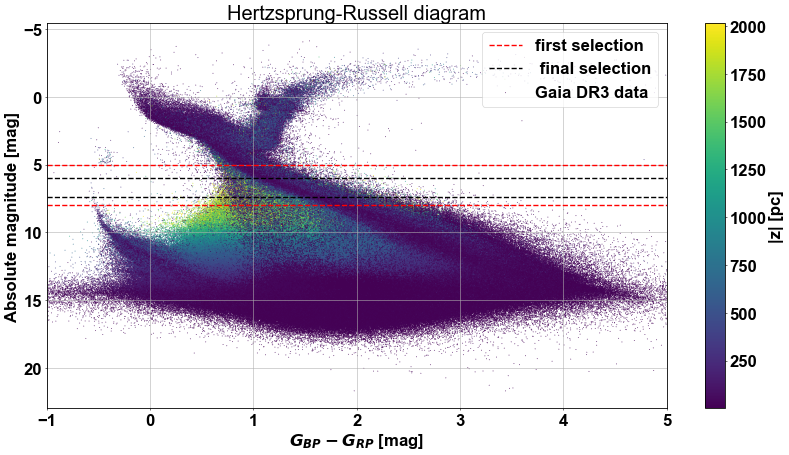

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
scatter = ax[0].scatter(bp_rp2, absolute_magnitude2, c=np.abs(z_pc2), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel(rf'$G_{{BP}}-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram')
ax[0].invert_yaxis()
ax[0].set_xlim(-1, 5)
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
fig.set_dpi(50)
plt.show()

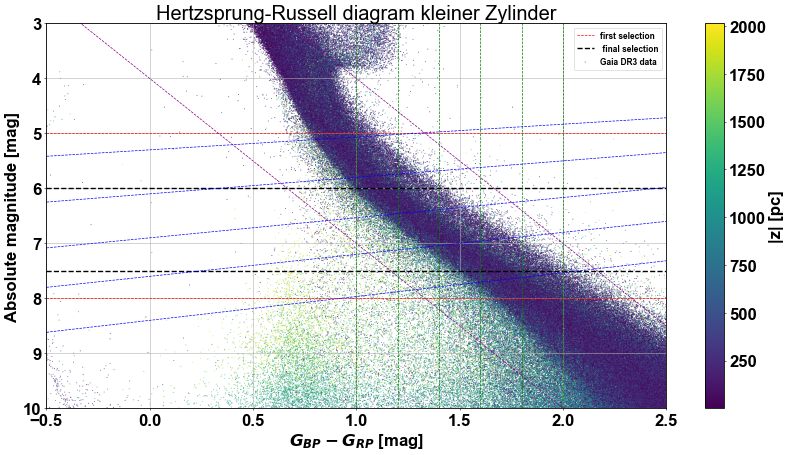

In [168]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=1, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=1)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.5, color='black', linestyle='--', linewidth=2, label=' final selection')
scatter = ax[0].scatter(bp_rp2[(r_pc2<100)], absolute_magnitude2[(r_pc2<100)], c=np.abs(z_pc2)[(r_pc2<100)], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].axvline(x=1.0, color='g', linestyle='--', linewidth=1)
ax[0].axvline(x=1.2, color='g', linestyle='--', linewidth=1)
ax[0].axvline(x=1.4, color='g', linestyle='--', linewidth=1)
ax[0].axvline(x=1.6, color='g', linestyle='--', linewidth=1)
ax[0].axvline(x=1.8, color='g', linestyle='--', linewidth=1)
ax[0].axvline(x=2.0, color='g', linestyle='--', linewidth=1)

x = np.array([-1,5])
ax[0].plot(x, 1.3 * (-1/3) * x + 8.4, color='b', linestyle='--', linewidth=1)
ax[0].plot(x, 1.2 * (-1/3) * x + 7.6, color='b', linestyle='--', linewidth=1)
ax[0].plot(x, 1.1 * (-1/3) * x + 6.9, color='b', linestyle='--', linewidth=1)
ax[0].plot(x, 0.9 * (-1/3) * x + 6.1, color='b', linestyle='--', linewidth=1)
ax[0].plot(x, 0.7 * (-1/3) * x + 5.3, color='b', linestyle='--', linewidth=1)

ax[0].plot(x, 3*x+4.0, color='purple', linestyle='--', linewidth=1)
ax[0].plot(x, 3*x+1.0, color='purple', linestyle='--', linewidth=1)



ax[0].grid()
ax[0].legend(loc='upper right', fontsize='12')

ax[0].set_xlabel(rf'$G_{{BP}}-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram kleiner Zylinder')
ax[0].invert_yaxis()
# ax[0].set_xlim(-0, 3)
# ax[0].set_ylim(8, 5)
ax[0].set_xlim(-0.5, 2.5)
ax[0].set_ylim(10, 3)
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
fig.set_dpi(50)
plt.show()

Anzahl Sterne im Bereich  1.0  < $G_{BP}-G_{RP}$ <  1.2 :  87033
Anzahl Sterne im Bereich  1.2  < $G_{BP}-G_{RP}$ <  1.4 :  163718
Anzahl Sterne im Bereich  1.4  < $G_{BP}-G_{RP}$ <  1.6 :  152859
Anzahl Sterne im Bereich  1.6  < $G_{BP}-G_{RP}$ <  1.8 :  62709
Anzahl Sterne im Bereich  1.8  < $G_{BP}-G_{RP}$ <  2.0 :  10244


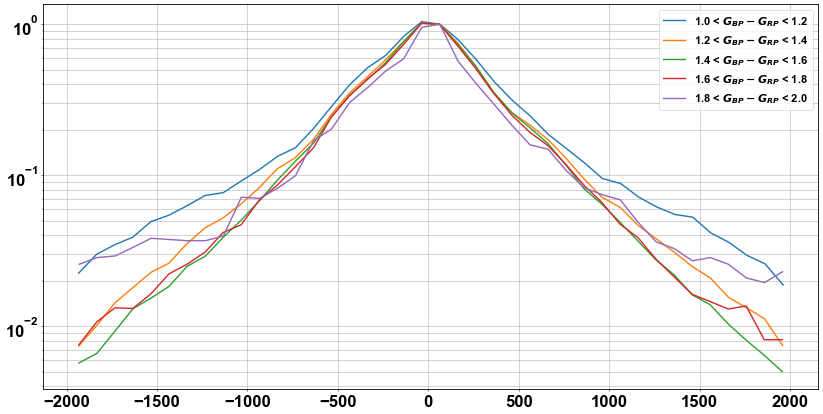

Range von 1.2 bis 1.6 sieht okay aus


In [62]:
aa = (absolute_magnitude2>=6.0)&(absolute_magnitude2<=7.5)
rr = r_pc2<200
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

for int in [[1.0,1.2], [1.2,1.4], [1.4,1.6], [1.6,1.8], [1.8,2.0]]:
    br = (bp_rp2[aa&rr]>=int[0]) & (bp_rp2[aa&rr]<=int[1])
    print('Anzahl Sterne im Bereich ', int[0], ' < $G_{BP}-G_{RP}$ < ', int[1], ': ', len(tab2[aa&rr][br]))
    n, bins = np.histogram(z_pc2[aa&rr][br], bins=40)
    ax.plot((bins[:-1]+bins[1:])/2, n/n[20], label=str(int[0])+' < $G_{BP}-G_{RP}$ < '+str(int[1]))

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()
print('Range von 1.2 bis 1.6 sieht okay aus')

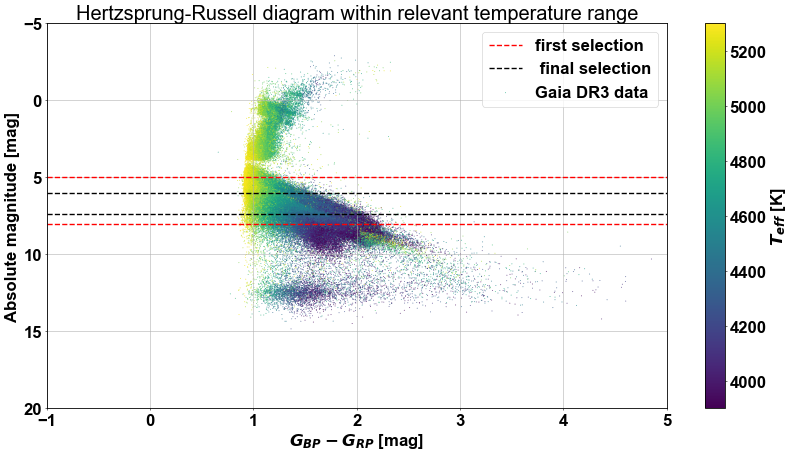

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')

scatter = ax[0].scatter(bp_rp2[(teff2<5300)&(teff2>3900)], absolute_magnitude2[(teff2<5300)&(teff2>3900)], c=teff2[(teff2<5300)&(teff2>3900)], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel(rf'$G_{{BP}}-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram within relevant temperature range')
ax[0].invert_yaxis()
ax[0].set_xlim(-1, 5)
ax[0].set_ylim(20,-5)
colorbar = fig.colorbar(scatter, ax=ax, label=rf'$T_{{eff}}$ [K]')
fig.set_dpi(50)
plt.show()

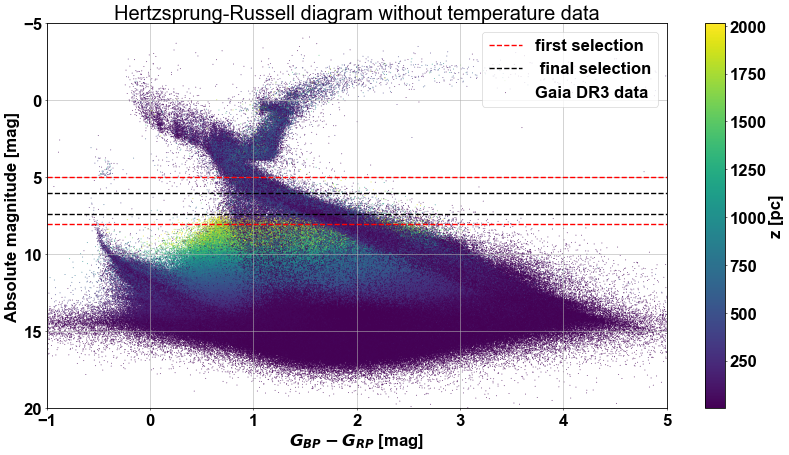

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')

scatter = ax[0].scatter(bp_rp2[np.isnan(teff2)], absolute_magnitude2[np.isnan(teff2)], c=abs(z_pc2[np.isnan(teff2)]), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel(rf'$G_{{BP}}-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram without temperature data')
ax[0].invert_yaxis()
ax[0].set_xlim(-1, 5)
ax[0].set_ylim(20,-5)
colorbar = fig.colorbar(scatter, ax=ax, label=rf'z [pc]')
fig.set_dpi(50)
plt.show()

In [67]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax = [ax]
# ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
# ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
# ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
# ax[0].axvline(x=4000, color='black', linestyle='--', linewidth=2)
# ax[0].axvline(x=5000, color='black', linestyle='--', linewidth=2)

# scatter = ax[0].scatter(teff2, absolute_magnitude2, c=np.abs(z_pc2), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

# ax[0].grid()
# ax[0].legend(loc='upper right')

# ax[0].set_xlabel('Effective temperature [K]')
# ax[0].set_ylabel('Absolute magnitude [mag]')
# ax[0].set_title('Hertzsprung-Russell diagram with temperature data')
# ax[0].invert_yaxis()
# ax[0].invert_xaxis()
# ax[0].set_xlim(6000, 2500)
# colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
# fig.set_dpi(50)
# plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


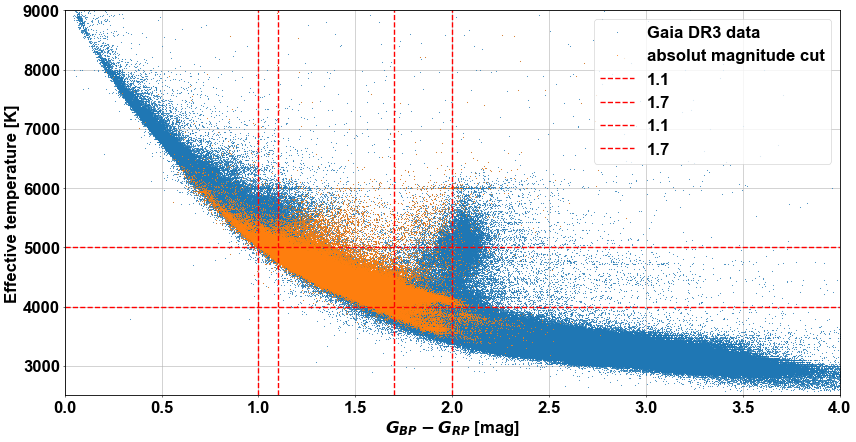

In [92]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot(bp_rp2, teff2, '.', markersize=1, label='Gaia DR3 data')
ax.plot(bp_rp2[aa&rr], teff2[aa&rr], '.', markersize=1, label='absolut magnitude cut')
plt.axhline(y=5000, color='r', linestyle='--', linewidth=2)
plt.axhline(y=4000, color='r', linestyle='--', linewidth=2)
plt.axvline(x=1.1, color='r', linestyle='--', linewidth=2, label='1.1')
plt.axvline(x=1.7, color='r', linestyle='--', linewidth=2, label='1.7')
plt.axvline(x=1.0, color='r', linestyle='--', linewidth=2, label='1.1')
plt.axvline(x=2.0, color='r', linestyle='--', linewidth=2, label='1.7')
ax.set_xlabel(rf'$G_{{BP}}-G_{{RP}}$ [mag]')
ax.set_ylabel('Effective temperature [K]')
ax.set_ylim(2500, 9000)
ax.set_xlim(0, 4)
plt.grid(which='both')
plt.legend()
fig.set_dpi(50)
plt.show()

In [68]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax.plot(g_rp2, teff2, '.', markersize=1, label='Gaia DR3 data')
# ax.plot(g_rp2[absmagcut&(np.abs(r_pc2)<100)], teff2[absmagcut&(np.abs(r_pc2)<100)], '.', markersize=1, label='selected stars')
# plt.axhline(y=5000, color='r', linestyle='--', linewidth=2)
# plt.axhline(y=4000, color='r', linestyle='--', linewidth=2)
# ax.set_xlabel(rf'$G-G_{{RP}}$ [mag]')
# ax.set_ylabel('Effective temperature [K]')
# ax.set_ylim(2500, 9000)
# ax.set_xlim(0, 1.5)
# plt.grid(which='both')
# fig.set_dpi(30)
# plt.show()

# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax.plot(bp_g2, teff2, '.', markersize=1, label='Gaia DR3 data')
# ax.plot(bp_g2[absmagcut&(np.abs(r_pc2)<100)], teff2[absmagcut&(np.abs(r_pc2)<100)], '.', markersize=1, label='selected stars')
# plt.axhline(y=5000, color='r', linestyle='--', linewidth=2)
# plt.axhline(y=4000, color='r', linestyle='--', linewidth=2)
# ax.set_xlabel(rf'$G_{{BP}}-G$ [mag]')
# ax.set_ylabel('Effective temperature [K]')
# ax.set_ylim(2500, 9000)
# ax.set_xlim(0, 2.5)
# plt.grid(which='both')
# fig.set_dpi(30)
# plt.show()

In [169]:
a = (absolute_magnitude2>=6.0)&(absolute_magnitude2<=7.5)
a1 = (absolute_magnitude2>=5)&(absolute_magnitude2<=6.2)
a2 = (absolute_magnitude2>=6.2)&(absolute_magnitude2<=6.4)
a3 = (absolute_magnitude2>=6.4)&(absolute_magnitude2<=6.6)
a4 = (absolute_magnitude2>=6.6)&(absolute_magnitude2<=7.0)
a5 = (absolute_magnitude2>=7.0)&(absolute_magnitude2<=7.2)
a6 = (absolute_magnitude2>=7.2)&(absolute_magnitude2<=7.4)
a7 = (absolute_magnitude2>=7.4)&(absolute_magnitude2<=8)

r = r_pc2<200
br = (bp_rp2>=1.2) & (bp_rp2<=1.8)
br2 = (bp_rp2>=1.0) & (bp_rp2<=2.0)
br3 = (bp_rp2>=1.4) & (bp_rp2<=1.6)
t = (teff2>=4000) & (teff2<=5000)

n1, bins1 = np.histogram(z_pc2[a&br2], bins=40)

n2, bins2 = np.histogram(z_pc2[a&br2][~np.isnan(teff2[a&br2])], bins=40)
n3, bins3 = np.histogram(z_pc2[a&br2][np.isnan(teff2[a&br2])], bins=40)
n4, bins4 = np.histogram(z_pc2[a&br2&t], bins=40)
n5, bins5 = np.histogram(z_pc2[a&t], bins=40,)

n6, bins6 = np.histogram(z_pc2[r&a1&br], bins=40)
n7, bins7 = np.histogram(z_pc2[r&a2&br], bins=40)
n8, bins8 = np.histogram(z_pc2[r&a3&br], bins=40)
n9, bins9 = np.histogram(z_pc2[r&a4&br], bins=40)
n10, bins10 = np.histogram(z_pc2[r&a5&br], bins=40)
n11, bins11 = np.histogram(z_pc2[r&a6&br], bins=40)
n12, bins12 = np.histogram(z_pc2[r&a7&br], bins=40)
print(np.sum(n6), np.sum(n7), np.sum(n8), np.sum(n9), np.sum(n10), np.sum(n11), np.sum(n12))

n13, bins13 = np.histogram(z_pc2[r&a1&br2], bins=40)
n14, bins14 = np.histogram(z_pc2[r&a2&br2], bins=40)
n15, bins15 = np.histogram(z_pc2[r&a3&br2], bins=40)
n16, bins16 = np.histogram(z_pc2[r&a4&br2], bins=40)
n17, bins17 = np.histogram(z_pc2[r&a5&br2], bins=40)
n18, bins18 = np.histogram(z_pc2[r&a6&br2], bins=40)
n19, bins19 = np.histogram(z_pc2[r&a7&br2], bins=40)
print(np.sum(n13), np.sum(n14), np.sum(n15), np.sum(n16), np.sum(n17), np.sum(n18), np.sum(n19))

n20, bins20 = np.histogram(z_pc2[r&a&br], bins=40)
n21, bins21 = np.histogram(z_pc2[r&a&br2], bins=40)
n22, bins22 = np.histogram(z_pc2[r&a&br3], bins=40)

abr = (absolute_magnitude2>=3*bp_rp2+1.0)&(absolute_magnitude2<=3*bp_rp2+4.0)
n23, bins23 = np.histogram(z_pc2[r&abr&a&br], bins=40)
n24, bins24 = np.histogram(z_pc2[r&abr&a&br2], bins=40)
n25, bins25 = np.histogram(z_pc2[r&abr&a&br3], bins=40)

26296 33778 52591 121878 62877 62918 149252
196614 60687 61545 126745 65812 67830 214280


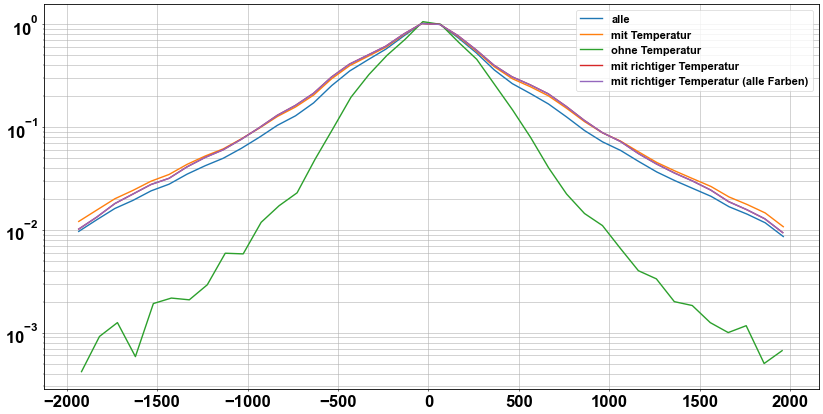

In [170]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins1[:-1]+bins1[1:])/2, n1/n1[20], label='alle')
ax.plot((bins2[:-1]+bins2[1:])/2, n2/n2[20], label='mit Temperatur')
ax.plot((bins3[:-1]+bins3[1:])/2, n3/n3[20], label='ohne Temperatur')
ax.plot((bins4[:-1]+bins4[1:])/2, n4/n4[20], label='mit richtiger Temperatur')
ax.plot((bins5[:-1]+bins5[1:])/2, n5/n5[20], label='mit richtiger Temperatur (alle Farben)')

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()

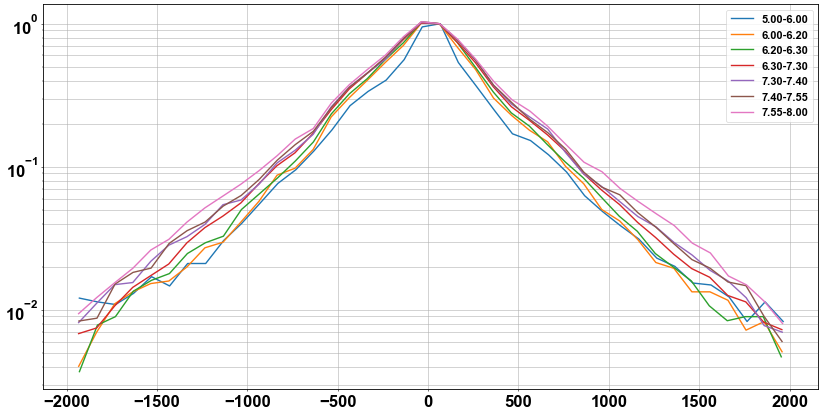

wieder 6.0 bis 7.5


In [171]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins6[:-1]+bins6[1:])/2, n6/n6[20], label='5.00-6.00')
ax.plot((bins7[:-1]+bins7[1:])/2, n7/n7[20], label='6.00-6.20')
ax.plot((bins8[:-1]+bins8[1:])/2, n8/n8[20], label='6.20-6.30')
ax.plot((bins9[:-1]+bins9[1:])/2, n9/n9[20], label='6.30-7.30')
ax.plot((bins10[:-1]+bins10[1:])/2, n10/n10[20], label='7.30-7.40')
ax.plot((bins11[:-1]+bins11[1:])/2, n11/n11[20], label='7.40-7.55')
ax.plot((bins12[:-1]+bins12[1:])/2, n12/n12[20], label='7.55-8.00')

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()

print('wieder 6.0 bis 7.5')

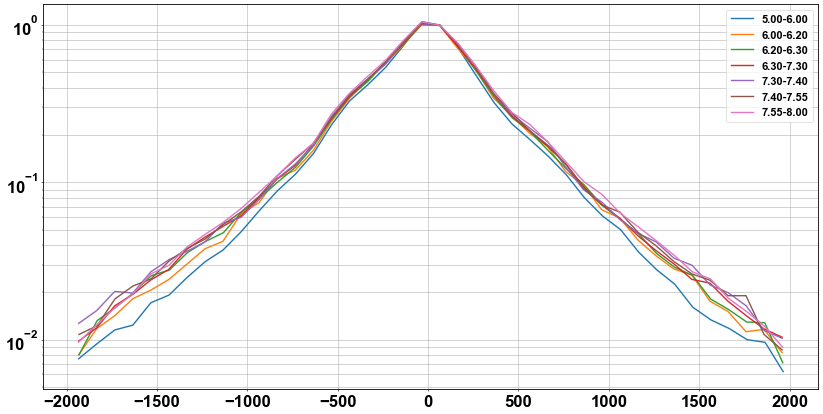

6.0 bis 8.0


In [172]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins13[:-1]+bins13[1:])/2, n13/n13[20], label='5.00-6.00')
ax.plot((bins14[:-1]+bins14[1:])/2, n14/n14[20], label='6.00-6.20')
ax.plot((bins15[:-1]+bins15[1:])/2, n15/n15[20], label='6.20-6.30')
ax.plot((bins16[:-1]+bins16[1:])/2, n16/n16[20], label='6.30-7.30')
ax.plot((bins17[:-1]+bins17[1:])/2, n17/n17[20], label='7.30-7.40')
ax.plot((bins18[:-1]+bins18[1:])/2, n18/n18[20], label='7.40-7.55')
ax.plot((bins19[:-1]+bins19[1:])/2, n19/n19[20], label='7.55-8.00')

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()

print('6.0 bis 8.0')

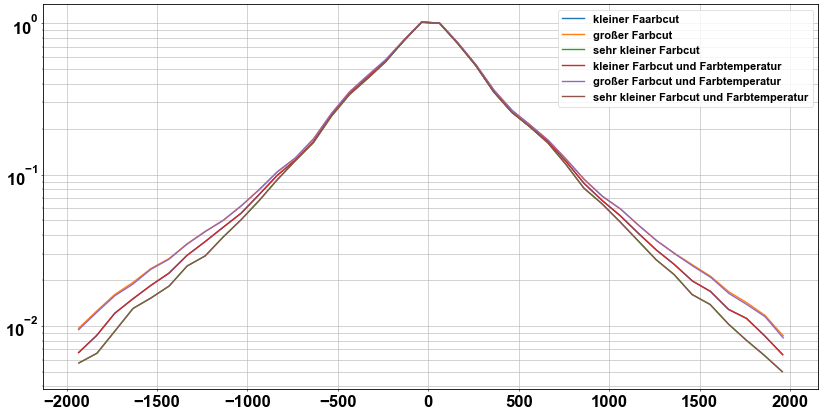

In [176]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins20[:-1]+bins20[1:])/2, n20/n20[20], label='kleiner Faarbcut')
ax.plot((bins21[:-1]+bins21[1:])/2, n21/n21[20], label='großer Farbcut')
ax.plot((bins22[:-1]+bins22[1:])/2, n22/n22[20], label='sehr kleiner Farbcut')
ax.plot((bins23[:-1]+bins23[1:])/2, n23/n23[20], label='kleiner Farbcut und Farbtemperatur')
ax.plot((bins24[:-1]+bins24[1:])/2, n24/n24[20], label='großer Farbcut und Farbtemperatur')
ax.plot((bins25[:-1]+bins25[1:])/2, n25/n25[20], label='sehr kleiner Farbcut und Farbtemperatur')

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()

C:\Users\Ruben\AppData\Local\Temp\ipykernel_25184\1653490263.py:9: RuntimeWarning: divide by zero encountered in log10
  m = M + 5.*np.log10(d) - 5.


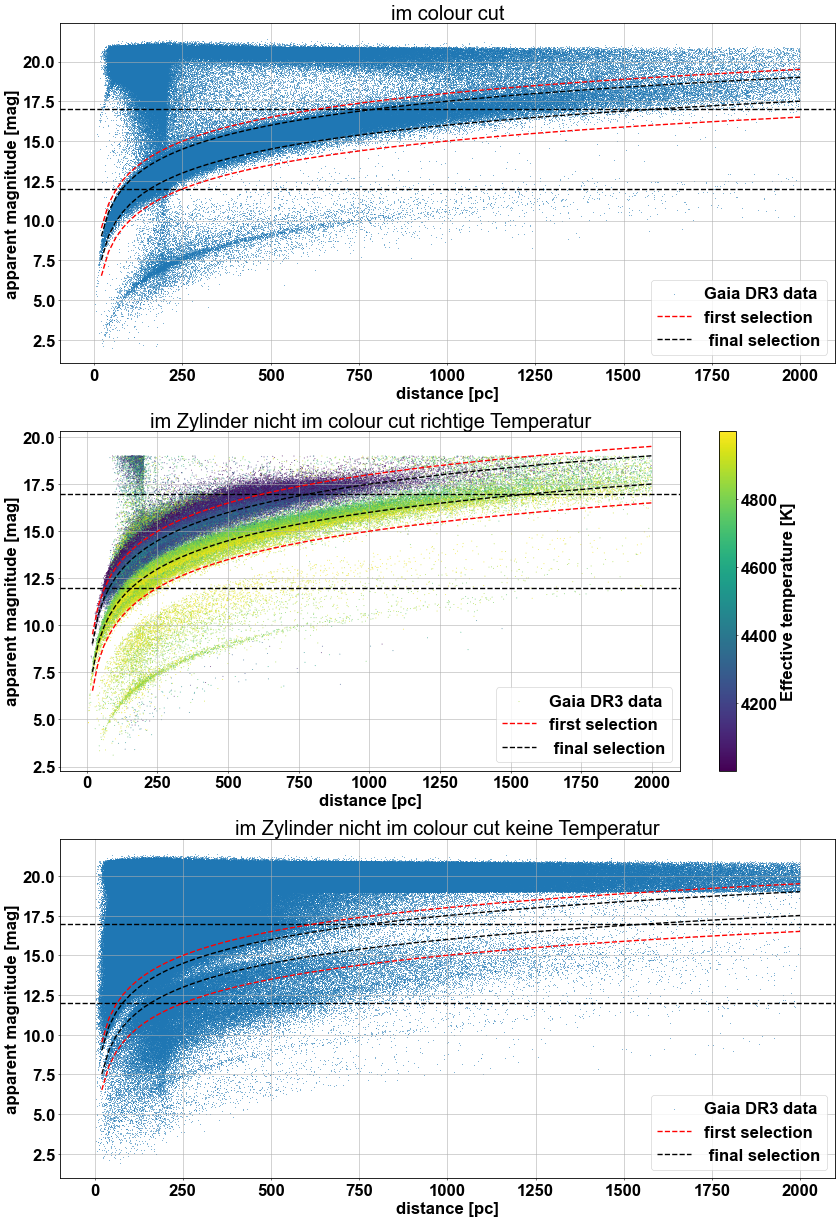

In [80]:
fig, ax = plt.subplots(3, 1, figsize=(20, 30))
ax[0].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=12, color='black', linestyle='--', linewidth=2)

scatter = ax[0].scatter(np.abs(dist_pc2[r&br]), apparent_magnitude2[r&br], marker='.', s=0.5, label='Gaia DR3 data')
z = np.linspace(0, 2000, 100)
ax[0].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[0].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[0].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[0].grid()
ax[0].legend(loc='lower right')

ax[0].set_ylabel('apparent magnitude [mag]')
ax[0].set_xlabel('distance [pc]')
ax[0].set_title('im colour cut')

ax[1].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[1].axhline(y=12, color='black', linestyle='--', linewidth=2)
scatter2 = ax[1].scatter(np.abs(dist_pc2[r&~br&(teff2>=4000)&(teff2<=5000)]), apparent_magnitude2[r&~br&(teff2>=4000)&(teff2<=5000)], marker='.', s=0.5, label='Gaia DR3 data', c=teff2[r&~br&(teff2>=4000)&(teff2<=5000)], cmap='viridis')
z = np.linspace(0, 2000, 100)
ax[1].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[1].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[1].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[1].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[1].grid()
ax[1].legend(loc='lower right')

ax[1].set_ylabel('apparent magnitude [mag]')
ax[1].set_xlabel('distance [pc]')
ax[1].set_title('im Zylinder nicht im colour cut richtige Temperatur')
colorbar2 = fig.colorbar(scatter2, ax=ax[1], label='Effective temperature [K]')

ax[2].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[2].axhline(y=12, color='black', linestyle='--', linewidth=2)

scatter3 = ax[2].scatter(np.abs(dist_pc2[r&~br&np.isnan(teff2)]), apparent_magnitude2[r&~br&np.isnan(teff2)], marker='.', s=0.5, label='Gaia DR3 data')
z = np.linspace(0, 2000, 100)
ax[2].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[2].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[2].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[2].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[2].grid()
ax[2].legend(loc='lower right')

ax[2].set_ylabel('apparent magnitude [mag]')
ax[2].set_xlabel('distance [pc]')
ax[2].set_title('im Zylinder nicht im colour cut keine Temperatur')

fig.set_dpi(50)
plt.show()

C:\Users\Ruben\AppData\Local\Temp\ipykernel_25184\1653490263.py:9: RuntimeWarning: divide by zero encountered in log10
  m = M + 5.*np.log10(d) - 5.


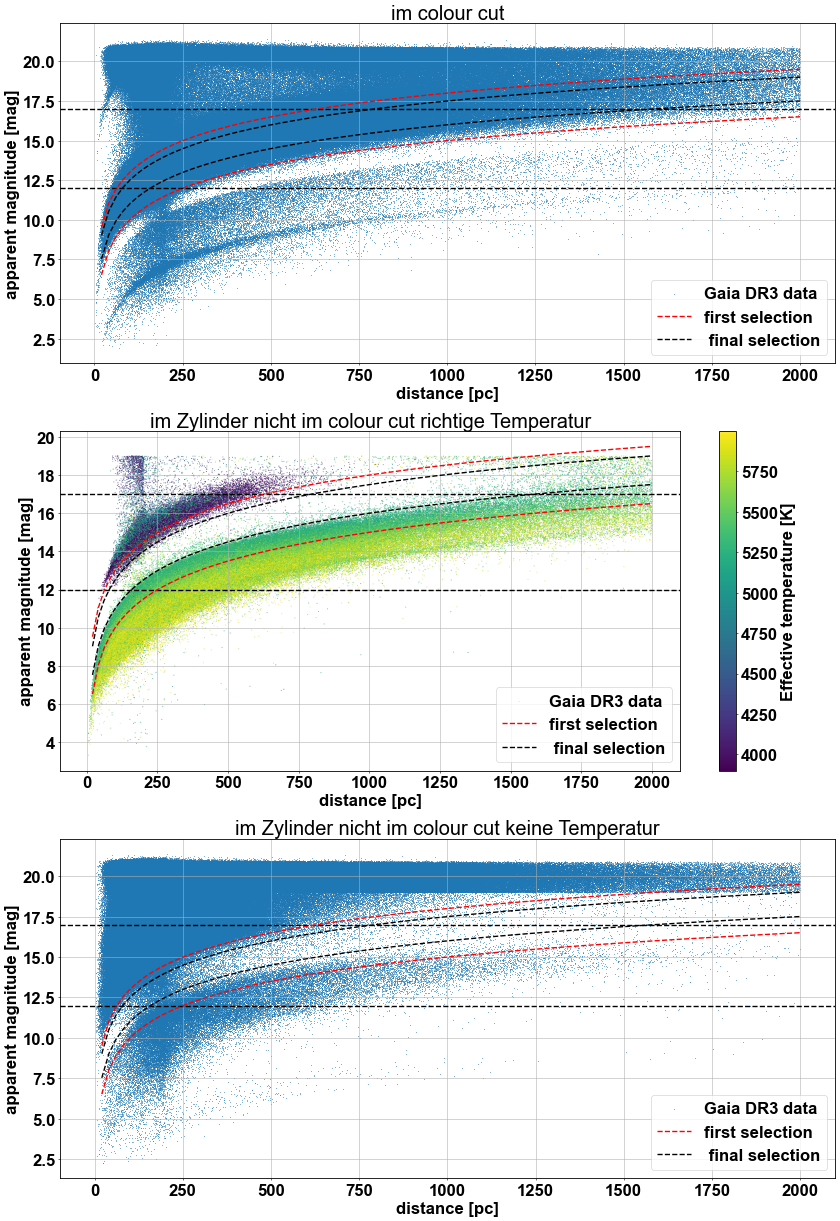

In [84]:
fig, ax = plt.subplots(3, 1, figsize=(20, 30))
ax[0].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=12, color='black', linestyle='--', linewidth=2)

scatter = ax[0].scatter(np.abs(dist_pc2[r&br2]), apparent_magnitude2[r&br2], marker='.', s=0.5, label='Gaia DR3 data')
z = np.linspace(0, 2000, 100)
ax[0].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[0].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[0].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[0].grid()
ax[0].legend(loc='lower right')

ax[0].set_ylabel('apparent magnitude [mag]')
ax[0].set_xlabel('distance [pc]')
ax[0].set_title('im colour cut')

ax[1].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[1].axhline(y=12, color='black', linestyle='--', linewidth=2)
scatter2 = ax[1].scatter(np.abs(dist_pc2[r&~br2&(teff2>=3900)&(teff2<=6000)]), apparent_magnitude2[r&~br2&(teff2>=3900)&(teff2<=6000)], marker='.', s=0.5, label='Gaia DR3 data', c=teff2[r&~br2&(teff2>=3900)&(teff2<=6000)], cmap='viridis')
z = np.linspace(0, 2000, 100)
ax[1].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[1].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[1].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[1].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[1].grid()
ax[1].legend(loc='lower right')

ax[1].set_ylabel('apparent magnitude [mag]')
ax[1].set_xlabel('distance [pc]')
ax[1].set_title('im Zylinder nicht im colour cut richtige Temperatur')
colorbar2 = fig.colorbar(scatter2, ax=ax[1], label='Effective temperature [K]')

ax[2].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[2].axhline(y=12, color='black', linestyle='--', linewidth=2)

scatter3 = ax[2].scatter(np.abs(dist_pc2[r&~br2&np.isnan(teff2)]), apparent_magnitude2[r&~br2&np.isnan(teff2)], marker='.', s=0.5, label='Gaia DR3 data')
z = np.linspace(0, 2000, 100)
ax[2].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[2].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[2].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[2].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[2].grid()
ax[2].legend(loc='lower right')

ax[2].set_ylabel('apparent magnitude [mag]')
ax[2].set_xlabel('distance [pc]')
ax[2].set_title('im Zylinder nicht im colour cut keine Temperatur')

fig.set_dpi(50)
plt.show()

In [43]:
print('Sterne im finalen Cut (kleiner Zyinder): ', len(tab2[r&br2&(absolute_magnitude2>=6.0)&(absolute_magnitude2<=7.5)]))
print('Sterne im finalen Cut (großer Zyinder): ', len(tab2[(r_pc2<200)&br2&(absolute_magnitude2>=6.0)&(absolute_magnitude2<=7.5)]))

Sterne im finalen Cut (kleiner Zyinder):  476563
Sterne im finalen Cut (großer Zyinder):  476563
